# Eclipse cross-sections from TROPoe

This notebook plots the time-height cross sections of atmospheric profiles duringvarious solar eclipses as observed from the ARM-run TROPoe retrievals and other AERI/ASSIST instruments.

In [1]:
# Start by loading the correct modules.

import numpy as np
import netCDF4
import matplotlib.pyplot as plt
import scipy.interpolate as interp

eclipseTime2017 = (18+4/60)
eclipseTime2023 = (16+48/60)
eclipseTime2024 = (18+47/60)
eclipseTimeSparc2024 = 19+4/60

nsa2017ds = netCDF4.Dataset('/data/eclipse/nsatropoeC1.c1.20170821.001002.nc')
nsa2023ds = netCDF4.Dataset('/data/eclipse/nsatropoeC1.c1.20231014.000502.nc')

sgp2017ds = netCDF4.Dataset('/data/eclipse/sgptropoeC1.c1.20170821.120003.nc')
sgp2023ds = netCDF4.Dataset('/data/eclipse/sgptropoeC1.c1.20231014.120018.nc')
sgp2024ds = netCDF4.Dataset('/data/eclipse/sgptropoeC1.c1.20240408.120008.nc')

sparc2024ds = netCDF4.Dataset('sparceclipsetropoe.c1.20240408.153334.nc')

def readAeri(ds):

    class out:
        
        time = ds['time'][:]/3600
        temp = ds['temperature'][:]
        height = ds['height'][:]
        wvmr = ds['waterVapor'][:]
        pblh = ds['pblh'][:]
        
    return out


nsa2017 = readAeri(nsa2017ds)
nsa2023 = readAeri(nsa2023ds)

sgp2017 = readAeri(sgp2017ds)
sgp2023 = readAeri(sgp2023ds)
sgp2024 = readAeri(sgp2024ds)

sparc2024 = readAeri(sparc2024ds)

In this cell, we'll be looking at straight cross-sections of the temperature.

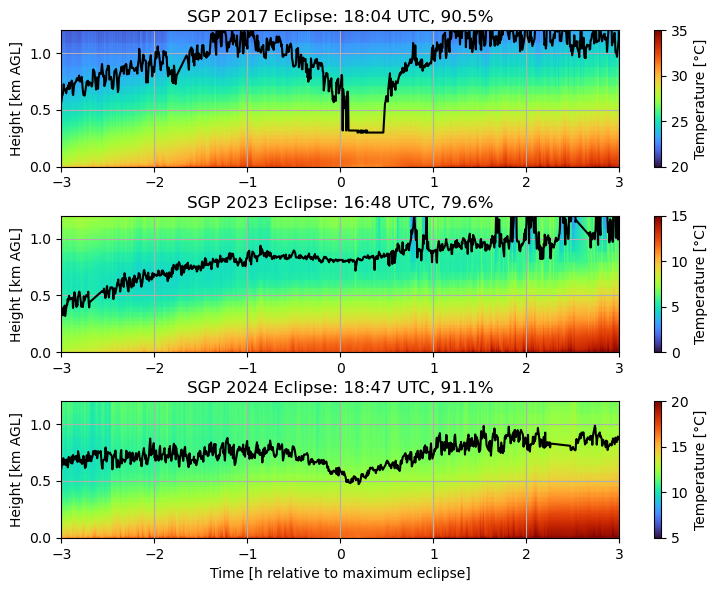

In [2]:
plt.figure(figsize=[9,9])

plt.subplot(4,1,1)
plt.pcolormesh(sgp2017.time-eclipseTime2017, sgp2017.height, np.transpose(sgp2017.temp),shading = 'gouraud',cmap='turbo')
plt.plot(sgp2017.time-eclipseTime2017, sgp2017.pblh, color='black')
plt.grid()
plt.ylim([0, 1.2])
plt.xlim([-3, 3])
plt.clim([20,35])
plt.colorbar(label='Temperature [°C]')
plt.title('SGP 2017 Eclipse: 18:04 UTC, 90.5%')
plt.ylabel('Height [km AGL]')


plt.subplot(4,1,2)
plt.pcolormesh(sgp2023.time-eclipseTime2023, sgp2023.height, np.transpose(sgp2023.temp),shading = 'gouraud',cmap='turbo')
plt.plot(sgp2023.time-eclipseTime2023, sgp2023.pblh,color='black')
plt.grid()
plt.ylim([0, 1.2])
plt.xlim([-3, 3])
plt.clim([0, 15])
plt.colorbar(label='Temperature [°C]')
plt.title('SGP 2023 Eclipse: 16:48 UTC, 79.6%')
plt.ylabel('Height [km AGL]')


plt.subplot(4,1,3)
plt.pcolormesh(sgp2024.time-eclipseTime2024, sgp2024.height, np.transpose(sgp2024.temp),shading = 'gouraud',cmap='turbo')
plt.plot(sgp2024.time-eclipseTime2024, sgp2024.pblh,color='black')
plt.grid()
plt.ylim([0, 1.2])
plt.xlim([-3, 3])
plt.clim([5, 20])
plt.colorbar(label='Temperature [°C]')
plt.title('SGP 2024 Eclipse: 18:47 UTC, 91.1%')
plt.ylabel('Height [km AGL]')
plt.xlabel('Time [h relative to maximum eclipse]')

plt.subplots_adjust(hspace=0.36)
plt.show()


Okay, now we're going to be doing changes relative to the max eclipse time.  First, we'll need to interpolate everything to a common time/.height grid so that we can do some easy differencing and averaging.

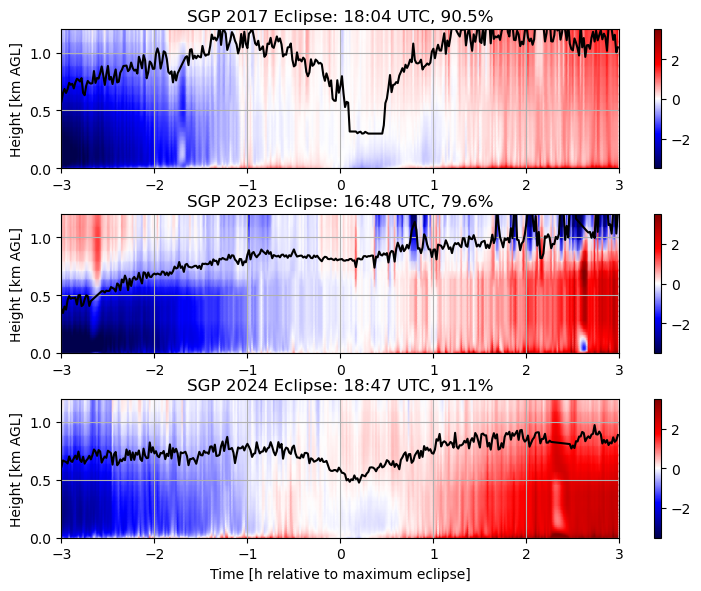

In [7]:
timeVec = np.arange(-3,3,1/60)
hghtVec = sgp2017.height


temp2017interpolant = interp.RectBivariateSpline(sgp2017.time-eclipseTime2017, sgp2017.height, sgp2017.temp)
temp2017interp = temp2017interpolant(timeVec, hghtVec)

temp2023interpolant = interp.RectBivariateSpline(sgp2023.time-eclipseTime2023, sgp2023.height, sgp2023.temp)
temp2023interp = temp2023interpolant(timeVec, hghtVec)

temp2024interpolant = interp.RectBivariateSpline(sgp2024.time-eclipseTime2024, sgp2024.height, sgp2024.temp)
temp2024interp = temp2024interpolant(timeVec, hghtVec)

tempSparc2024interpolant = interp.RectBivariateSpline(sparc2024.time-eclipseTimeSparc2024, sparc2024.height, sparc2024.temp)
tempSparc2024interp = tempSparc2024interpolant(timeVec, hghtVec)

temp2017delta = temp2017interp-np.tile(temp2017interp[180,:],(360,1))
temp2023delta = temp2023interp-np.tile(temp2023interp[180,:],(360,1))
temp2024delta = temp2024interp-np.tile(temp2024interp[180,:],(360,1))
tempSparc2024delta = tempSparc2024interp-np.tile(tempSparc2024interp[180,:],(360,1))

# Also interpolate the PBLH values.

pbl2017=np.interp(timeVec,sgp2017.time-eclipseTime2017, sgp2017.pblh)
pbl2023=np.interp(timeVec,sgp2023.time-eclipseTime2023, sgp2023.pblh)
pbl2024=np.interp(timeVec,sgp2024.time-eclipseTime2024, sgp2024.pblh)
pblSparc2024=np.interp(timeVec,sparc2024.time-eclipseTimeSparc2024, sparc2024.pblh)

plt.figure(figsize=[9,9])

plt.subplot(4,1,1)
eclipseTime = (18+4/60)
plt.pcolormesh(timeVec, hghtVec, np.transpose(temp2017delta),shading = 'gouraud',cmap='seismic')
plt.plot(timeVec, pbl2017,color='black')
plt.grid()
plt.clim([-3.5,3.5])
plt.ylim([0, 1.2])
plt.xlim([-3, 3])
plt.colorbar()
plt.title('SGP 2017 Eclipse: 18:04 UTC, 90.5%')
plt.ylabel('Height [km AGL]')

plt.subplot(4,1,2)
eclipseTime = (16+48/60)
plt.pcolormesh(timeVec, hghtVec, np.transpose(temp2023delta),shading = 'gouraud',cmap='seismic')
plt.plot(timeVec, pbl2023,color='black')
plt.grid()
plt.ylim([0, 1.2])
plt.xlim([-3, 3])
plt.clim([-3.5,3.5])
plt.colorbar()
plt.title('SGP 2023 Eclipse: 16:48 UTC, 79.6%')
plt.ylabel('Height [km AGL]')

plt.subplot(4,1,3)
eclipseTime = (18+47/60)
plt.pcolormesh(timeVec, hghtVec, np.transpose(temp2024delta),shading = 'gouraud',cmap='seismic')
plt.plot(timeVec, pbl2024,color='black')
plt.grid()
plt.ylim([0, 1.2])
plt.xlim([-3, 3])
plt.clim([-3.5,3.5])
plt.colorbar()
plt.title('SGP 2024 Eclipse: 18:47 UTC, 91.1%')
plt.ylabel('Height [km AGL]')
plt.xlabel('Time [h relative to maximum eclipse]')

plt.subplots_adjust(hspace=0.33)
plt.show()

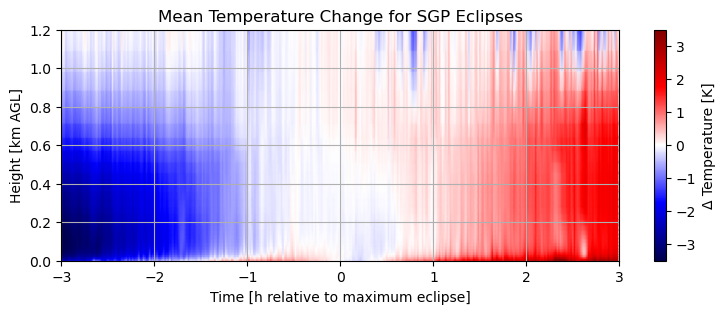

In [8]:
allTemps = np.array([temp2017delta, temp2023delta, temp2024delta])

meanTemps = np.mean(allTemps, axis=0)

plt.figure(figsize=[9,3])
plt.pcolormesh(timeVec, hghtVec, np.transpose(meanTemps),shading = 'gouraud',cmap='seismic')
plt.ylim([0, 1.2])
plt.xlim([-3, 3])
plt.clim([-3.5,3.5])
plt.colorbar(label='Δ Temperature [K]')
plt.title('Mean Temperature Change for SGP Eclipses')
plt.ylabel('Height [km AGL]')
plt.xlabel('Time [h relative to maximum eclipse]')
plt.grid()
plt.show()

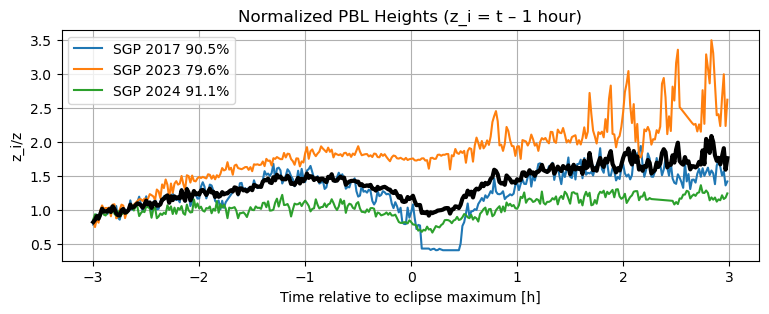

In [9]:
pbl2017norm = pbl2017/pbl2017[20]
pbl2023norm = pbl2023/pbl2023[20]
pbl2024norm = pbl2024/pbl2024[20]


plt.figure(figsize=[9,3])
plt.plot(timeVec, pbl2017norm,label='SGP 2017 90.5%')
plt.plot(timeVec, pbl2023norm,label='SGP 2023 79.6%')
plt.plot(timeVec, pbl2024norm,label='SGP 2024 91.1%')
plt.plot(timeVec, np.mean(np.array([pbl2017norm, pbl2023norm, pbl2024norm]),axis=0),linewidth=3,color='black')
plt.grid()

plt.title('Normalized PBL Heights (z_i = t – 1 hour)')
plt.xlabel('Time relative to eclipse maximum [h]')
plt.ylabel('z_i/z')
plt.legend()

In [6]:
temp2017interp.shape

(360, 55)